## Libary Import and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)

data_dir = Path("data/raw")
adjusted_dir = Path("data/adjusted")
adjusted_dir.mkdir(parents=True, exist_ok=True)

csv_files = [
    "policecalls2022.csv",
    "policecalls2023.csv",
    "policecalls2024.csv",
    "policecalls2025.csv",
    "policecalls2026.csv",
]

missing_files = [f for f in csv_files if not (data_dir / f).exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing files in {data_dir.resolve()}: {missing_files}"
    )

df_list = []
for file in csv_files:
    full_path = data_dir / file
    # Keep CDTS as string to avoid numeric/scientific coercion during load.
    temp = pd.read_csv(full_path, dtype={"CDTS": "string"}, low_memory=False)
    temp["source_file"] = file
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df.shape)
display(df.head())
df.info()

print("\nColumns:")
print(df.columns.tolist())

print("\nRows by source file:")
display(df["source_file"].value_counts())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))
print(f"\nAdjusted output folder: {adjusted_dir.resolve()}")

Combined shape: (1206883, 17)


,CDTS,EID,START_DATE,CALL_NUMBER,PRIORITY,REPORT_DATE,OFFENSE_DATE,OFFENSE_TIME,CALLTYPE_CODE,CALL_TYPE,FINAL_DISPO_CODE,FINAL_DISPO,ADDRESS,CITY,STATE,source_file,UNHOUSED
0,20220101042916PS,8913184,1/1/2022 12:00:00 AM,P220010180,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,02:49:02,1066,SUSPICIOUS PERSON,N,No report required; dispatch record only,[800]-[900] JEANNE AV,San Jose,CA,policecalls2022.csv,NaN
1,20220101043036PS,8913196,1/1/2022 12:00:00 AM,P220010191,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,03:05:51,415,DISTURBANCE,N,No report required; dispatch record only,[1500]-[1600] SOUTHWEST EX,San Jose,CA,policecalls2022.csv,NaN
2,20220101043827PS,8913252,1/1/2022 12:00:00 AM,P220010236,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,04:35:25,911UNK,UNK TYPE 911 CALL,CAN,Canceled,[4800]-[4900] WESTMONT AV,San Jose,CA,policecalls2022.csv,NaN
3,20220101044026PS,8913216,1/1/2022 12:00:00 AM,P220010206,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,03:38:14,SUSCIR,SUSPICIOUS CIRCUMSTANCES,N,No report required; dispatch record only,[3600]-[3700] GREENLEE DR,San Jose,CA,policecalls2022.csv,NaN
4,20220102052501PS,8914182,1/1/2022 12:00:00 AM,P220010965,4,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,23:25:49,11300,NARCOTICS,A,Arrest Made,E CAPITOL EX & EVERGREEN PL,San Jose,CA,policecalls2022.csv,NaN


<class 'pandas.DataFrame'>
RangeIndex: 1206883 entries, 0 to 1206882
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   CDTS              1206883 non-null  string
 1   EID               1206883 non-null  int64 
 2   START_DATE        1206883 non-null  str   
 3   CALL_NUMBER       1206883 non-null  str   
 4   PRIORITY          1206883 non-null  int64 
 5   REPORT_DATE       1206883 non-null  str   
 6   OFFENSE_DATE      1206883 non-null  str   
 7   OFFENSE_TIME      1206883 non-null  str   
 8   CALLTYPE_CODE     1206883 non-null  str   
 9   CALL_TYPE         1206883 non-null  str   
 10  FINAL_DISPO_CODE  1206883 non-null  str   
 11  FINAL_DISPO       1206883 non-null  str   
 12  ADDRESS           1172773 non-null  str   
 13  CITY              1206883 non-null  str   
 14  STATE             1206883 non-null  str   
 15  source_file       1206883 non-null  str   
 16  UNHOUSED          32718 non-n

source_file
policecalls2022.csv    294515
policecalls2023.csv    286481
policecalls2024.csv    272506
policecalls2025.csv    262095
policecalls2026.csv     91286
Name: count, dtype: int64


Missing values:


UNHOUSED            1174165
ADDRESS               34110
CALL_TYPE                 0
source_file               0
STATE                     0
CITY                      0
FINAL_DISPO               0
FINAL_DISPO_CODE          0
CDTS                      0
EID                       0
OFFENSE_TIME              0
OFFENSE_DATE              0
REPORT_DATE               0
PRIORITY                  0
CALL_NUMBER               0
START_DATE                0
CALLTYPE_CODE             0
dtype: int64


Adjusted output folder: /Users/user/Downloads/Quantifying-Breakpoint-of-SJPD-Response/data/adjusted


## Clean and Parse

In [2]:
def parse_cdts_series(raw_series: pd.Series) -> pd.Series:
    # Normalize raw values and remove known suffix noise.
    s = (
        raw_series.astype("string")
                  .str.upper()
                  .str.replace("PS", "", regex=False)
                  .str.strip()
    )

    # Primary parse: first 14 digits interpreted as YYYYMMDDHHMMSS.
    digits14 = s.str.extract(r"(\d{14})", expand=False)
    parsed = pd.to_datetime(digits14, format="%Y%m%d%H%M%S", errors="coerce")

    # Secondary parse: 12-digit timestamps (YYYYMMDDHHMM) -> append seconds.
    missing_mask = parsed.isna()
    if missing_mask.any():
        digits12 = s[missing_mask].str.extract(r"(\d{12})", expand=False)
        parsed12 = pd.to_datetime(digits12 + "00", format="%Y%m%d%H%M%S", errors="coerce")
        parsed.loc[missing_mask] = parsed12.values

    # Final fallback: let pandas infer any remaining odd formats.
    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed_fallback = pd.to_datetime(s[missing_mask], errors="coerce")
        parsed.loc[missing_mask] = parsed_fallback.values

    return parsed

def parse_mixed_datetime_column(raw_series: pd.Series) -> pd.Series:
    s = raw_series.astype("string").str.strip()
    parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

    fmt_candidates = [
        "%Y%m%d%H%M%S",
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%d %H:%M",
        "%m/%d/%Y %H:%M:%S",
        "%m/%d/%Y",
        "%Y/%m/%d %H:%M:%S",
        "%Y/%m/%d",
    ]

    for fmt in fmt_candidates:
        mask = parsed.isna()
        if not mask.any():
            break
        parsed_fmt = pd.to_datetime(s[mask], format=fmt, errors="coerce")
        parsed.loc[mask] = parsed_fmt.values

    # Generic fallback for any rows still unparsed.
    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values

    return parsed

# Robust per-row parsing for CDTS.
df["CDTS"] = parse_cdts_series(df["CDTS"])

for col in ["START_DATE", "REPORT_DATE", "OFFENSE_DATE"]:
    if col in df.columns:
        df[col] = parse_mixed_datetime_column(df[col])

display(df[["CDTS"]].head())
print("Missing CDTS after parsing:", int(df["CDTS"].isna().sum()))

print("\nRows by parsed year:")
display(df["CDTS"].dt.year.value_counts().sort_index())

print("\nMonth coverage by source file (parsed CDTS):")
month_coverage = (
    df.dropna(subset=["CDTS"])
      .groupby(["source_file", df["CDTS"].dt.month])["CDTS"]
      .size()
      .unstack(fill_value=0)
      .reindex(columns=range(1, 13), fill_value=0)
)
display(month_coverage)

bad_cdts_sample = df.loc[df["CDTS"].isna(), ["source_file", "CDTS"]].head(10)
if not bad_cdts_sample.empty:
    print("\nSample unparsed CDTS rows (first 10):")
    display(bad_cdts_sample)

/var/folders/bb/k9821jvx5hdcdrfqjlz9c2l40000gn/T/ipykernel_12678/3643479539.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values


/var/folders/bb/k9821jvx5hdcdrfqjlz9c2l40000gn/T/ipykernel_12678/3643479539.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values


/var/folders/bb/k9821jvx5hdcdrfqjlz9c2l40000gn/T/ipykernel_12678/3643479539.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values


,CDTS
0,2022-01-01 04:29:16
1,2022-01-01 04:30:36
2,2022-01-01 04:38:27
3,2022-01-01 04:40:26
4,2022-01-02 05:25:01


Missing CDTS after parsing: 0

Rows by parsed year:


CDTS
2022    294473
2023    286471
2024    272508
2025    262109
2026     91322
Name: count, dtype: int64


Month coverage by source file (parsed CDTS):


CDTS,1,2,3,4,5,6,7,8,9,10,11,12
source_file,,,,,,,,,,,,
policecalls2022.csv,23390,21332,25315,23553,27064,26030,23623,26737,26074,26065,22617,22715
policecalls2023.csv,23559,21021,23440,23624,25346,24434,25499,24854,24046,24405,22524,23729
policecalls2024.csv,21485,21464,23064,21315,23832,23145,24245,23537,22937,23575,21670,22237
policecalls2025.csv,21317,19586,22620,21180,23693,22298,22817,23586,21905,21284,20508,21301
policecalls2026.csv,20595,18425,30668,21598,0,0,0,0,0,0,0,0


## Clean the key analysis Columns

In [3]:
df["PRIORITY"] = pd.to_numeric(df["PRIORITY"], errors="coerce")
df["FINAL_DISPO"] = df["FINAL_DISPO"].astype(str).str.strip()
df["CALL_TYPE"] = df["CALL_TYPE"].astype(str).str.strip()

df = df.dropna(subset=["CDTS", "PRIORITY"]).copy()
df = df.sort_values("CDTS").reset_index(drop=True)

print("Cleaned shape:", df.shape)

print("\nPriority distribution:")
display(df["PRIORITY"].value_counts().sort_index())

print("\nTop FINAL_DISPO values:")
display(df["FINAL_DISPO"].value_counts().head(20))

print("\nTop CALL_TYPE values:")
display(df["CALL_TYPE"].value_counts().head(20))

print("\nRows by source file after cleaning:")
display(df["source_file"].value_counts())

print("\nRows by year after cleaning:")
display(df["CDTS"].dt.year.value_counts().sort_index())

# Write cleaned per-file outputs without changing raw source files.
for file_name, chunk in df.groupby("source_file", sort=False):
    out_path = adjusted_dir / file_name
    chunk.drop(columns=["source_file"], errors="ignore").to_csv(out_path, index=False)

combined_out_path = adjusted_dir / "policecalls_adjusted_all.csv"
df.drop(columns=["source_file"], errors="ignore").to_csv(combined_out_path, index=False)

print(f"\nSaved cleaned files to: {adjusted_dir.resolve()}")
print(f"Combined cleaned file: {combined_out_path.resolve()}")

Cleaned shape: (1206883, 17)

Priority distribution:


PRIORITY
1     38150
2    376093
3    420968
4    139978
5     80413
6    151280
8         1
Name: count, dtype: int64


Top FINAL_DISPO values:


FINAL_DISPO
No report required; dispatch record only            539853
Canceled                                            242704
Report taken                                        168355
Gone on Arrival/unable to locate                     50340
No Disposition                                       41899
Arrest Made                                          25873
Traffic Citation Issued, Hazardous Violation         23454
Traffic Citation Issued, Non-Hazardous Violation     23286
Supplemental report taken                            20480
Unfounded event                                      19101
Courtesy Service/Citizen or agency assist            14706
Criminal Citation                                    10840
Turned over To (TOT)                                 10291
Arrest by Warrant                                     8741
Field Interview (F.I.) Completed                      3761
No Response                                           2942
Stranded motorist assist                    


Top CALL_TYPE values:


...


Rows by source file after cleaning:


source_file
policecalls2022.csv    294515
policecalls2023.csv    286481
policecalls2024.csv    272506
policecalls2025.csv    262095
policecalls2026.csv     91286
Name: count, dtype: int64


Rows by year after cleaning:


CDTS
2022    294473
2023    286471
2024    272508
2025    262109
2026     91322
Name: count, dtype: int64


Saved cleaned files to: /Users/user/Downloads/Quantifying-Breakpoint-of-SJPD-Response/data/adjusted
Combined cleaned file: /Users/user/Downloads/Quantifying-Breakpoint-of-SJPD-Response/data/adjusted/policecalls_adjusted_all.csv


## Data quality and coverage report

In [4]:
key_fields = [field for field in ["CDTS", "PRIORITY", "CALL_TYPE", "FINAL_DISPO", "ADDRESS", "CITY"] if field in df.columns]

duplicate_mask = df.duplicated(subset=["CALL_NUMBER", "CDTS"], keep=False) if "CALL_NUMBER" in df.columns else df.duplicated(keep=False)

quality_summary = pd.DataFrame(
    {
        "metric": [
            "rows_after_cleaning",
            "duplicate_rows",
            "date_min",
            "date_max",
            "distinct_call_types",
            "distinct_dispositions",
            "distinct_addresses"
        ],
        "value": [
            len(df),
            int(duplicate_mask.sum()),
            df["CDTS"].min(),
            df["CDTS"].max(),
            int(df["CALL_TYPE"].nunique(dropna=True)) if "CALL_TYPE" in df.columns else np.nan,
            int(df["FINAL_DISPO"].nunique(dropna=True)) if "FINAL_DISPO" in df.columns else np.nan,
            int(df["ADDRESS"].nunique(dropna=True)) if "ADDRESS" in df.columns else np.nan
        ]
    }
)

field_completeness = (
    df[key_fields].notna()
      .mean()
      .mul(100)
      .round(2)
      .rename("non_null_pct")
      .reset_index()
      .rename(columns={"index": "field"})
)

coverage_by_year_month = (
    df.groupby([df["CDTS"].dt.year.rename("year"), df["CDTS"].dt.month.rename("month")], observed=False)
      .size()
      .unstack(fill_value=0)
      .reindex(columns=range(1, 13), fill_value=0)
)

display(quality_summary)
display(field_completeness)
display(coverage_by_year_month)

,metric,value
0,rows_after_cleaning,1206883
1,duplicate_rows,17545
2,date_min,2022-01-01 00:03:07
3,date_max,2026-04-27 06:29:31
4,distinct_call_types,211
5,distinct_dispositions,18
6,distinct_addresses,52493


,field,non_null_pct
0,CDTS,100.00
1,PRIORITY,100.00
2,CALL_TYPE,100.00
3,FINAL_DISPO,100.00
4,ADDRESS,97.17
5,CITY,100.00


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2022,23348,21332,25315,23553,27064,26030,23623,26737,26074,26065,22617,22715
2023,23549,21021,23440,23624,25346,24434,25499,24854,24046,24405,22524,23729
2024,21487,21464,23064,21315,23832,23145,24245,23537,22937,23575,21670,22237
2025,21331,19586,22620,21180,23693,22298,22817,23586,21905,21284,20508,21301
2026,20631,18425,30668,21598,0,0,0,0,0,0,0,0


## Create time-based features

In [5]:
df["year"] = df["CDTS"].dt.year
df["month"] = df["CDTS"].dt.month
# Keep as datetime (not Python date objects) for faster grouping/resampling.
df["day"] = df["CDTS"].dt.floor("D")
df["hour"] = df["CDTS"].dt.hour
df["day_of_week"] = df["CDTS"].dt.day_name()
df["is_weekend"] = df["CDTS"].dt.dayofweek >= 5

display(df[["CDTS", "year", "month", "day", "hour", "day_of_week", "is_weekend"]].head())

,CDTS,year,month,day,hour,day_of_week,is_weekend
0,2022-01-01 00:03:07,2022,1,2022-01-01,0,Saturday,True
1,2022-01-01 00:03:54,2022,1,2022-01-01,0,Saturday,True
2,2022-01-01 00:06:18,2022,1,2022-01-01,0,Saturday,True
3,2022-01-01 00:08:03,2022,1,2022-01-01,0,Saturday,True
4,2022-01-01 00:11:15,2022,1,2022-01-01,0,Saturday,True


## Creating flags for canceled calls and priority groups

In [6]:
df["FINAL_DISPO_upper"] = df["FINAL_DISPO"].str.upper()
df["is_canceled"] = df["FINAL_DISPO_upper"].str.contains("CANCEL", na=False)

df["is_p1"] = df["PRIORITY"] == 1
df["is_p3_p4"] = df["PRIORITY"].isin([3, 4])
df["is_canceled_p3_p4"] = df["is_canceled"] & df["is_p3_p4"]

display(df[["PRIORITY", "FINAL_DISPO", "is_canceled", "is_p1", "is_p3_p4", "is_canceled_p3_p4"]].head())

,PRIORITY,FINAL_DISPO,is_canceled,is_p1,is_p3_p4,is_canceled_p3_p4
0,4,Canceled,True,False,True,True
1,2,Canceled,True,False,False,False
2,4,Canceled,True,False,True,True
3,4,Canceled,True,False,True,True
4,6,No report required; dispatch record only,False,False,False,False


## basic descriptive EDA

In [7]:
# Faster than groupby-size for single-key counts on large data.
daily_calls = (
    df["day"].value_counts(sort=False)
      .sort_index()
      .rename_axis("day")
      .reset_index(name="total_calls")
)
hourly_calls = (
    df["hour"].value_counts(sort=False)
      .sort_index()
      .rename_axis("hour")
      .reset_index(name="total_calls")
)

priority_counts = df["PRIORITY"].value_counts().sort_index().reset_index()
priority_counts.columns = ["PRIORITY", "count"]

cancel_by_priority = (
    df.groupby("PRIORITY", sort=True, observed=False)
      .agg(
          total_calls=("PRIORITY", "size"),
          canceled_calls=("is_canceled", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

cancel_by_priority["cancel_rate"] = cancel_by_priority["canceled_calls"] / cancel_by_priority["total_calls"]

display(daily_calls.head())
display(hourly_calls.head())
display(priority_counts)
display(cancel_by_priority)

,day,total_calls
0,2022-01-01,794
1,2022-01-02,726
2,2022-01-03,804
3,2022-01-04,796
4,2022-01-05,848


,hour,total_calls
0,0,66153
1,1,52340
2,2,39694
3,3,31750
4,4,25392


,PRIORITY,count
0,1,38150
1,2,376093
2,3,420968
3,4,139978
4,5,80413
5,6,151280
6,8,1


,PRIORITY,total_calls,canceled_calls,canceled_p3_p4,cancel_rate
0,1,38150,1916,0,0.050223
1,2,376093,61160,0,0.162619
2,3,420968,118096,118096,0.280534
3,4,139978,59368,59368,0.424124
4,5,80413,656,0,0.008158
5,6,151280,1507,0,0.009962
6,8,1,1,0,1.000000


## Plot the basic desc patterns

Filled 3 missing calendar days with 0 calls.
Daily chart downsampled to 789 points using 2-day bins.


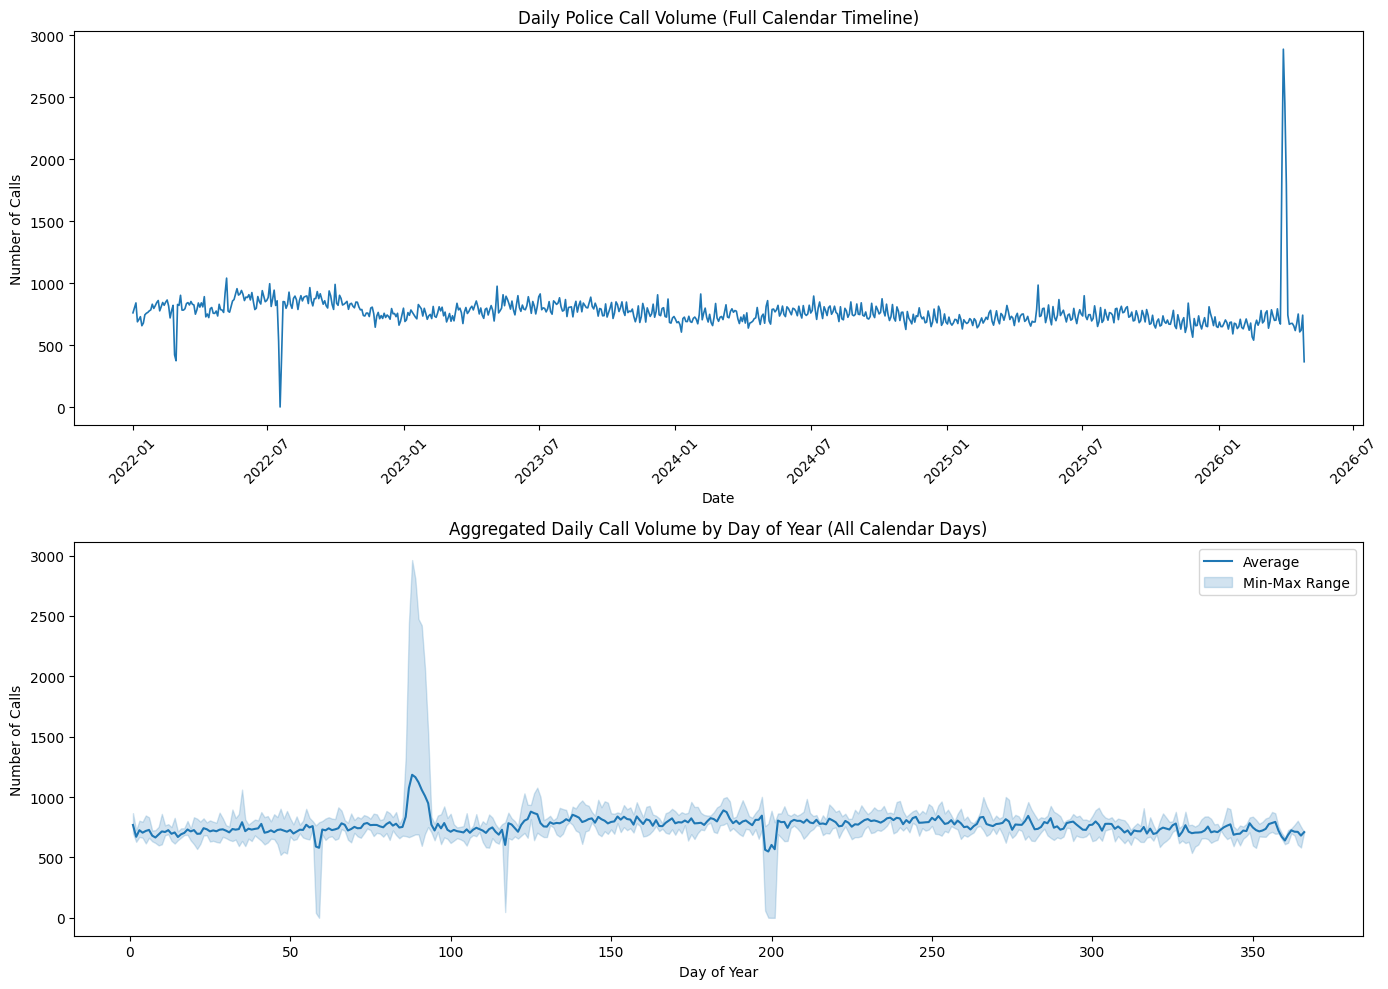

,day_of_year,avg_calls,min_calls,max_calls,sample_days
0,1,769.2,702,867,5
1,2,671.0,629,726,5
2,3,725.6,670,804,5
3,4,705.2,663,796,5
4,5,719.6,616,848,5
5,6,728.2,663,832,5
6,7,680.8,634,723,5
7,8,665.2,620,726,5
8,9,691.0,600,754,5
9,10,715.6,609,861,5


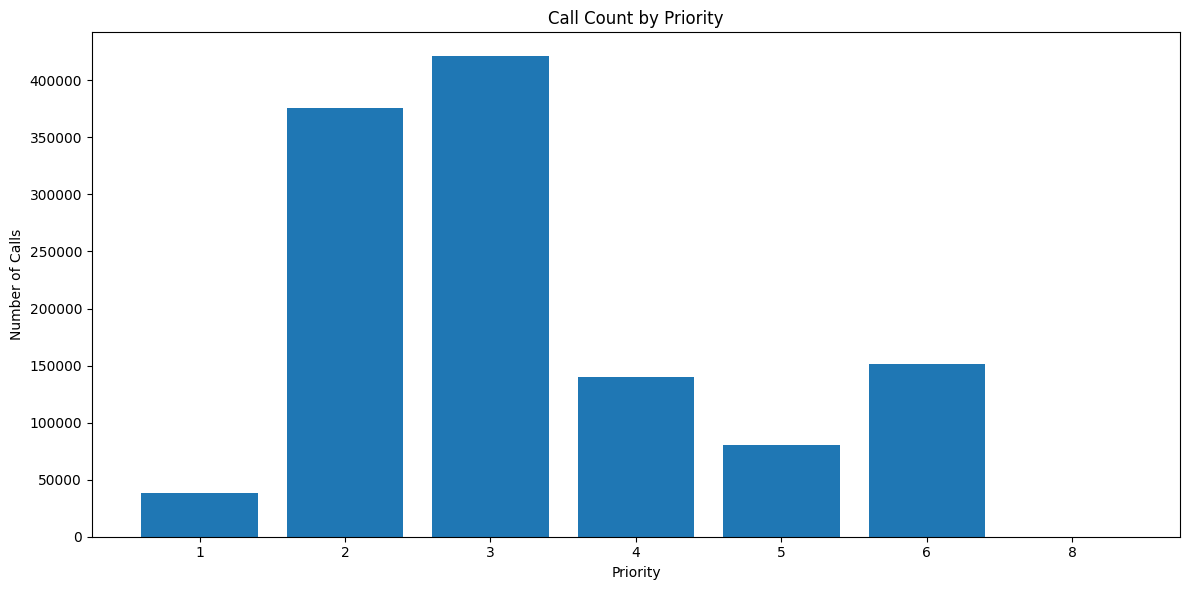

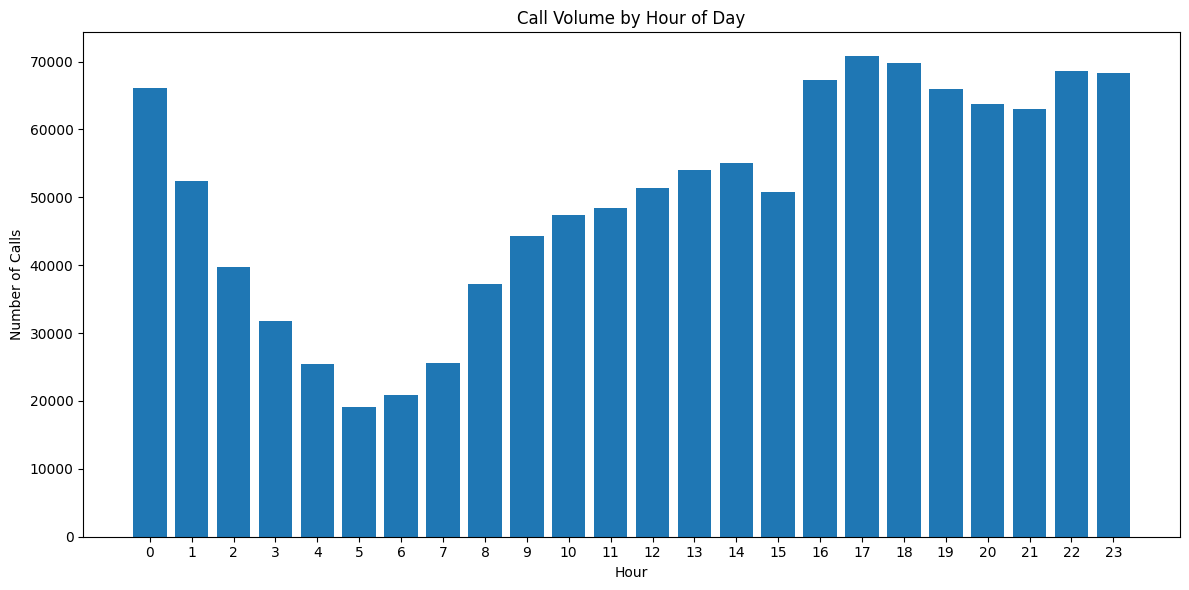

In [8]:
# Reuse pre-aggregated daily counts to avoid re-scanning the full dataframe.
daily_observed = daily_calls.copy()
daily_observed["day"] = pd.to_datetime(daily_observed["day"])

# Build a full calendar timeline and fill missing days with 0 so every day is represented.
full_day_index = pd.date_range(
    daily_observed["day"].min(),
    daily_observed["day"].max(),
    freq="D"
)
daily_timeline = (
    daily_observed.set_index("day")
                  .reindex(full_day_index, fill_value=0)
                  .rename_axis("day")
                  .reset_index()
                  .rename(columns={"index": "day"})
)
daily_timeline["total_calls"] = daily_timeline["total_calls"].astype("int32")

missing_day_count = int(len(full_day_index) - len(daily_observed))
print(f"Filled {missing_day_count:,} missing calendar days with 0 calls.")

# Keep plotting responsive by downsampling only for visualization when needed.
daily_plot = daily_timeline
max_daily_points = 900
if len(daily_plot) > max_daily_points:
    plot_bin_days = max(int(np.ceil(len(daily_plot) / max_daily_points)), 1)
    daily_plot = (
        daily_plot.set_index("day")["total_calls"]
                 .resample(f"{plot_bin_days}D")
                 .mean()
                 .reset_index()
    )
    print(f"Daily chart downsampled to {len(daily_plot):,} points using {plot_bin_days}-day bins.")
else:
    print(f"Daily chart uses full daily resolution ({len(daily_plot):,} points).")

# Aggregate all calendar days-of-year (1..366) from the full timeline.
doy_stats = (
    daily_timeline.assign(day_of_year=daily_timeline["day"].dt.dayofyear)
                  .groupby("day_of_year", sort=True, as_index=True)["total_calls"]
                  .agg(avg_calls="mean", min_calls="min", max_calls="max", sample_days="size")
)

# Fast fixed-size index to guarantee full 1..366 coverage.
doy_profile = (
    doy_stats.reindex(np.arange(1, 367))
             .rename_axis("day_of_year")
             .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(daily_plot["day"], daily_plot["total_calls"], linewidth=1.2)
axes[0].set_title("Daily Police Call Volume (Full Calendar Timeline)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Calls")
axes[0].tick_params(axis="x", rotation=45)

valid_doy = doy_profile.dropna(subset=["avg_calls", "min_calls", "max_calls"])
axes[1].plot(valid_doy["day_of_year"], valid_doy["avg_calls"], color="tab:blue", label="Average")
axes[1].fill_between(
    valid_doy["day_of_year"],
    valid_doy["min_calls"],
    valid_doy["max_calls"],
    color="tab:blue",
    alpha=0.2,
    label="Min-Max Range"
)
axes[1].set_title("Aggregated Daily Call Volume by Day of Year (All Calendar Days)")
axes[1].set_xlabel("Day of Year")
axes[1].set_ylabel("Number of Calls")
axes[1].legend()

plt.tight_layout()
plt.show()

display(doy_profile.head(10))

plt.figure()
plt.bar(priority_counts["PRIORITY"].astype(str), priority_counts["count"])
plt.title("Call Count by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(hourly_calls["hour"].astype(str), hourly_calls["total_calls"])
plt.title("Call Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

## Workload and cancellation patterns by weekday and hour

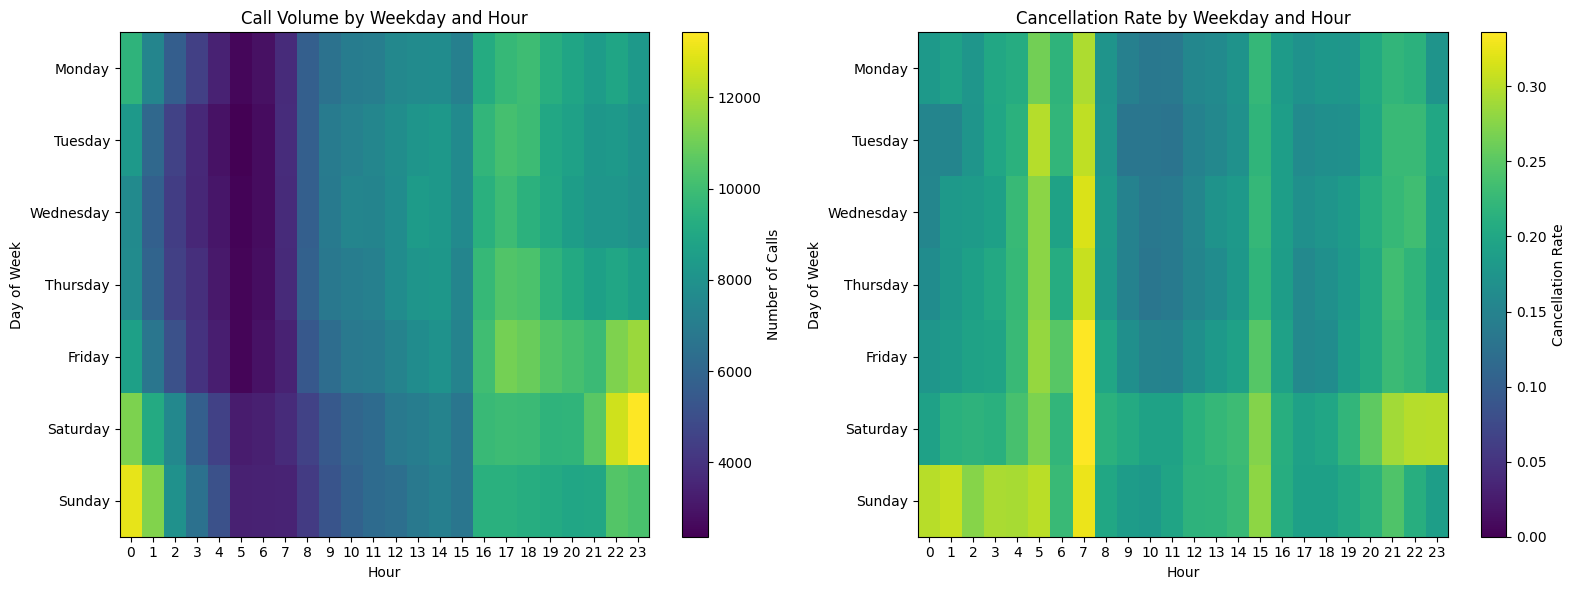

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,9562,7396,5677,4450,3451,2583,2880,3733,5719,6550,...,7768,7179,9161,9783,9988,9314,8876,8477,8851,8367
Tuesday,8295,6108,4572,3641,2891,2372,2745,3788,5717,6975,...,8261,7679,9649,10179,9934,8996,8701,8214,8326,8008
Wednesday,7647,5756,4366,3602,3033,2484,2747,3750,5720,6945,...,8275,7677,9392,9933,9492,9049,8505,8171,8164,7971
Thursday,7704,5918,4472,3850,3122,2505,2788,3683,5793,6816,...,8235,7412,9792,10411,10282,9557,9100,8632,8893,8564
Friday,8656,6692,5101,4004,3298,2526,2908,3422,5437,6311,...,8024,7335,10026,11101,10915,10442,10145,9892,11270,11746


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,0.180,0.192,0.176,0.202,0.208,0.264,0.218,0.294,0.174,0.146,...,0.173,0.224,0.184,0.171,0.178,0.176,0.204,0.221,0.216,0.174
Tuesday,0.153,0.153,0.176,0.199,0.214,0.298,0.221,0.304,0.177,0.132,...,0.171,0.219,0.188,0.162,0.167,0.169,0.199,0.227,0.227,0.200
Wednesday,0.154,0.181,0.185,0.190,0.227,0.278,0.194,0.316,0.183,0.148,...,0.180,0.224,0.188,0.169,0.175,0.184,0.209,0.224,0.233,0.192
Thursday,0.164,0.179,0.191,0.203,0.225,0.277,0.208,0.308,0.180,0.148,...,0.179,0.220,0.187,0.158,0.169,0.180,0.202,0.233,0.220,0.190
Friday,0.177,0.185,0.193,0.197,0.228,0.283,0.249,0.335,0.199,0.167,...,0.192,0.248,0.192,0.158,0.163,0.186,0.204,0.229,0.221,0.203


In [9]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

workload_heat = (
    df.groupby(["day_of_week", "hour"], observed=False)
      .size()
      .unstack(fill_value=0)
      .reindex(day_order)
      .reindex(columns=range(24), fill_value=0)
)

cancel_rate_heat = (
    df.groupby(["day_of_week", "hour"], observed=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum")
      )
)
cancel_rate_heat["cancel_rate"] = np.where(
    cancel_rate_heat["total_calls"] > 0,
    cancel_rate_heat["canceled_calls"] / cancel_rate_heat["total_calls"],
    np.nan
)
cancel_rate_heat = (
    cancel_rate_heat["cancel_rate"]
        .unstack()
        .reindex(day_order)
        .reindex(columns=range(24))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

workload_im = axes[0].imshow(workload_heat, aspect="auto")
axes[0].set_title("Call Volume by Weekday and Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Day of Week")
axes[0].set_xticks(range(24))
axes[0].set_yticks(range(len(workload_heat.index)), workload_heat.index)
fig.colorbar(workload_im, ax=axes[0], label="Number of Calls")

cancel_im = axes[1].imshow(cancel_rate_heat, aspect="auto", vmin=0, vmax=np.nanmax(cancel_rate_heat.to_numpy()))
axes[1].set_title("Cancellation Rate by Weekday and Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Day of Week")
axes[1].set_xticks(range(24))
axes[1].set_yticks(range(len(cancel_rate_heat.index)), cancel_rate_heat.index)
fig.colorbar(cancel_im, ax=axes[1], label="Cancellation Rate")

plt.tight_layout()
plt.show()

display(workload_heat.head())
display(cancel_rate_heat.round(3).head())

## Aggregate the data into operational workload windows

In [10]:
time_bin_size = "15min"
df["time_bin"] = df["CDTS"].dt.floor(time_bin_size)

df["is_priority_1"] = (df["PRIORITY"] == 1).astype("int8")

agg = (
    df.groupby("time_bin", as_index=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum"),
          priority_1_calls=("is_priority_1", "sum"),
          unique_call_types=("CALL_TYPE", "nunique")
      )
)

agg["cancel_rate"] = np.where(
    agg["total_calls"] > 0,
    agg["canceled_calls"] / agg["total_calls"],
    np.nan
)
agg["priority_1_share"] = np.where(
    agg["total_calls"] > 0,
    agg["priority_1_calls"] / agg["total_calls"],
    np.nan
)

display(agg.head())
display(agg[["total_calls", "canceled_calls", "cancel_rate", "priority_1_share", "unique_call_types"]].describe())

,time_bin,total_calls,canceled_calls,priority_1_calls,unique_call_types,cancel_rate,priority_1_share
0,2022-01-01 00:00:00,6,5,0,3,0.833333,0.000000
1,2022-01-01 00:15:00,7,6,0,1,0.857143,0.000000
2,2022-01-01 00:30:00,10,4,0,6,0.400000,0.000000
3,2022-01-01 00:45:00,6,1,1,6,0.166667,0.166667
4,2022-01-01 01:00:00,13,7,2,10,0.538462,0.153846


,total_calls,canceled_calls,cancel_rate,priority_1_share,unique_call_types
count,149309.000000,149309.000000,149309.000000,149309.000000,149309.000000
mean,8.083123,1.625515,0.202651,0.035021,6.427483
std,4.414439,1.675501,0.192587,0.087242,2.952198
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,5.000000,0.000000,0.000000,0.000000,4.000000
50%,8.000000,1.000000,0.166667,0.000000,6.000000
75%,11.000000,2.000000,0.300000,0.000000,8.000000
max,80.000000,27.000000,1.000000,1.000000,22.000000


## Plot operational surge indicators

Plot downsampled to 1,498 points using 90850s bins.


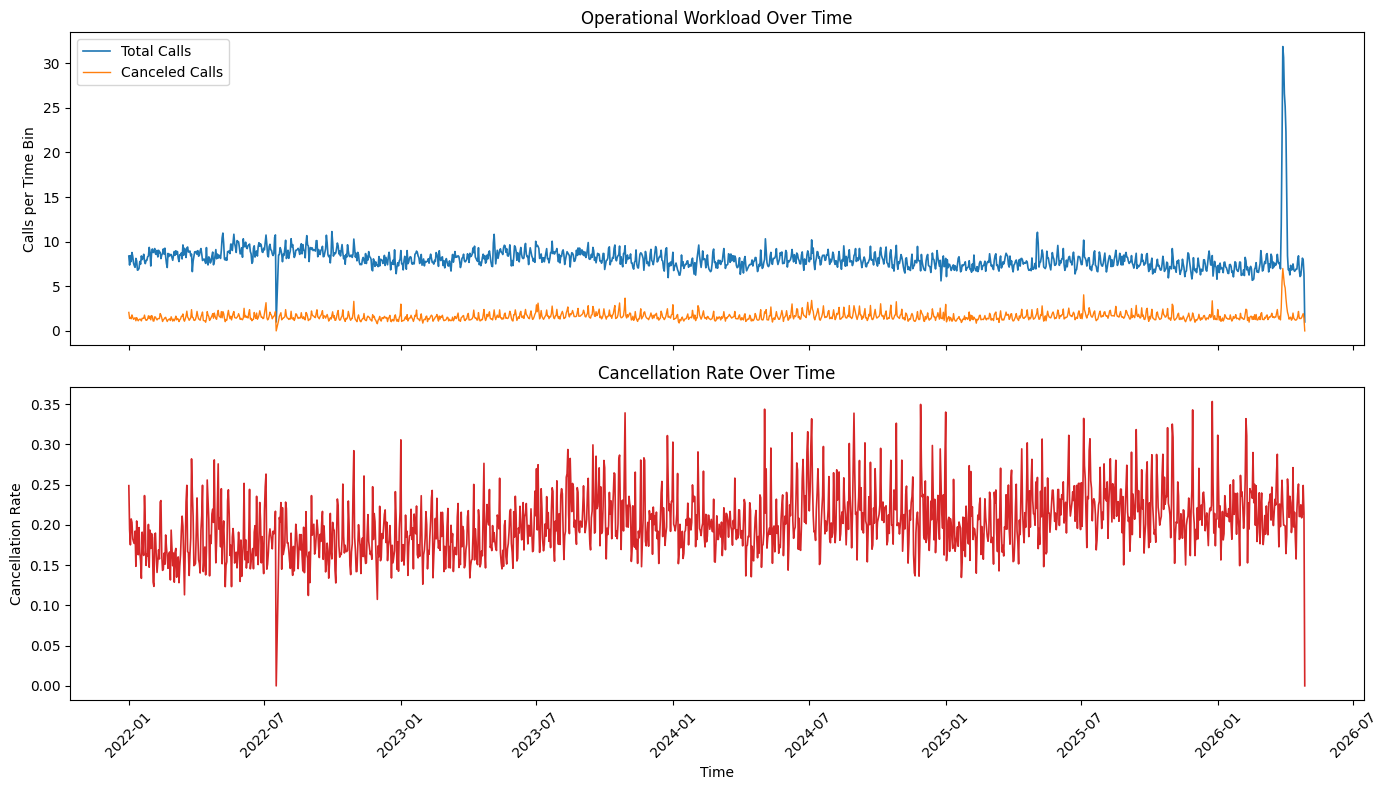

In [11]:
plot_agg = agg.sort_values("time_bin").copy()
max_plot_points = 1500

if len(plot_agg) > max_plot_points:
    total_span_seconds = max(
        (plot_agg["time_bin"].max() - plot_agg["time_bin"].min()).total_seconds(),
        1
    )
    resample_seconds = max(int(total_span_seconds / max_plot_points), 1)
    resample_rule = f"{resample_seconds}s"

    plot_agg = (
        plot_agg.set_index("time_bin")[["total_calls", "canceled_calls", "cancel_rate"]]
               .resample(resample_rule)
               .mean()
               .dropna(how="all")
               .reset_index()
    )
    print(f"Plot downsampled to {len(plot_agg):,} points using {resample_rule} bins.")
else:
    print(f"Plot uses full resolution ({len(plot_agg):,} points).")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(plot_agg["time_bin"], plot_agg["total_calls"], label="Total Calls", linewidth=1.2)
axes[0].plot(plot_agg["time_bin"], plot_agg["canceled_calls"], label="Canceled Calls", linewidth=1.0)
axes[0].set_title("Operational Workload Over Time")
axes[0].set_ylabel("Calls per Time Bin")
axes[0].legend()

axes[1].plot(plot_agg["time_bin"], plot_agg["cancel_rate"], color="tab:red", linewidth=1.2)
axes[1].set_title("Cancellation Rate Over Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Cancellation Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare calm and busy workload windows

In [12]:
agg["workload_band"] = pd.qcut(
    agg["total_calls"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"],
    duplicates="drop"
)

workload_compare = (
    agg.groupby("workload_band", observed=False)
       .agg(
           windows=("time_bin", "count"),
           avg_total_calls=("total_calls", "mean"),
           avg_canceled_calls=("canceled_calls", "mean"),
           avg_cancel_rate=("cancel_rate", "mean"),
           avg_unique_call_types=("unique_call_types", "mean")
       )
       .reset_index()
)

display(workload_compare)

,workload_band,windows,avg_total_calls,avg_canceled_calls,avg_cancel_rate,avg_unique_call_types
0,Low,45328,3.486940,0.733300,0.216244,3.196788
1,Moderate,41303,6.999056,1.350483,0.193084,5.981599
2,High,33461,9.902155,1.902992,0.192129,7.979648
3,Very High,29217,14.663004,3.080741,0.207138,10.292364


## Find highest-demand windows and locations

,time_bin,total_calls,canceled_calls,priority_1_calls,unique_call_types,cancel_rate,priority_1_share,workload_band
146555,2026-03-28 23:45:00,80,27,3,16,0.337500,0.037500,Very High
146553,2026-03-28 23:15:00,79,15,0,11,0.189873,0.000000,Very High
146723,2026-03-30 18:15:00,76,20,8,14,0.263158,0.105263,Very High
146720,2026-03-30 17:30:00,67,24,8,14,0.358209,0.119403,Very High
146722,2026-03-30 18:00:00,67,4,0,15,0.059701,0.000000,Very High
146563,2026-03-29 01:45:00,66,11,4,14,0.166667,0.060606,Very High
146647,2026-03-29 23:00:00,65,20,0,13,0.307692,0.000000,Very High
146894,2026-04-01 13:00:00,64,16,0,15,0.250000,0.000000,Very High
146728,2026-03-30 19:30:00,64,0,0,12,0.000000,0.000000,Very High
146898,2026-04-01 14:00:00,61,12,0,11,0.196721,0.000000,Very High


,ADDRESS,total_calls,canceled_calls,cancel_rate
0,[2800]-[2900] STEVENS CREEK BL,6260,2363,0.377476
1,[900]-[1000] BLOSSOM HILL RD,4140,1128,0.272464
2,[2100]-[2200] MONTEREY RD,3842,579,0.150703
3,[500]-[600] COLEMAN AV,3448,742,0.215197
4,[1700]-[1800] AIRPORT BL,2931,203,0.069260
5,[0]-[100] W MISSION ST,2681,476,0.177546
6,Not a valid geographical location in CAD.,2653,468,0.176404
7,[0]-[100] SARATOGA AV,2262,610,0.269673
8,[100]-[200] AIRPORT BL,2258,167,0.073959
9,[200]-[300] W MISSION ST,2203,384,0.174308


,CITY,total_calls
0,San Jose,1206883


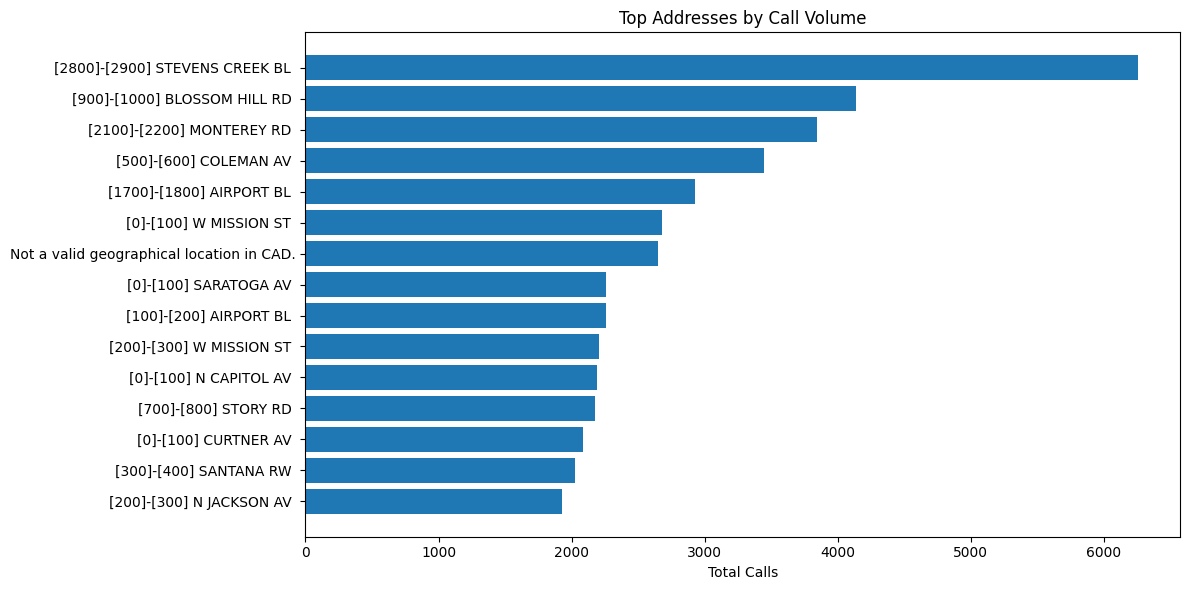

In [13]:
top_stress_windows = agg.sort_values(
    ["total_calls", "canceled_calls", "cancel_rate"],
    ascending=[False, False, False]
).head(20)

top_addresses = (
    df.dropna(subset=["ADDRESS"])
.groupby("ADDRESS", observed=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum")
      )
)
top_addresses["cancel_rate"] = np.where(
    top_addresses["total_calls"] > 0,
    top_addresses["canceled_calls"] / top_addresses["total_calls"],
    np.nan
)
top_addresses = (
    top_addresses.sort_values(["total_calls", "canceled_calls"], ascending=[False, False])
                 .head(15)
                 .reset_index()
)

top_cities = (
    df.dropna(subset=["CITY"])
.groupby("CITY", observed=False)
      .agg(total_calls=("CDTS", "size"))
      .sort_values("total_calls", ascending=False)
      .head(10)
      .reset_index()
)

display(top_stress_windows)
display(top_addresses)
display(top_cities)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_addresses["ADDRESS"].iloc[::-1], top_addresses["total_calls"].iloc[::-1])
ax.set_title("Top Addresses by Call Volume")
ax.set_xlabel("Total Calls")

plt.tight_layout()
plt.show()

## Profile call types and dispositions

,CALL_TYPE,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,VEHICLE STOP,126770,1271,7,0.010026,0.000055
1,DISTURBANCE,112619,29519,495,0.262114,0.004395
2,WELFARE CHECK,97273,17317,896,0.178025,0.009211
3,"ALARM, AUDIBLE",85988,45924,1784,0.534075,0.020747
4,PARKING VIOLATION,57572,10711,1,0.186045,0.000017
5,"DISTURBANCE, MUSIC",39747,30285,1,0.761944,0.000025
6,"DISTURBANCE, FAMILY",39185,4746,379,0.121118,0.009672
7,SUSPICIOUS PERSON,36536,9002,147,0.246387,0.004023
8,TRESPASSING,34225,10527,128,0.307582,0.003740
9,SUSPICIOUS VEHICLE,34069,5830,10,0.171123,0.000294


,FINAL_DISPO,total_calls
0,No report required; dispatch record only,539853
1,Canceled,242704
2,Report taken,168355
3,Gone on Arrival/unable to locate,50340
4,No Disposition,41899
5,Arrest Made,25873
6,"Traffic Citation Issued, Hazardous Violation",23454
7,"Traffic Citation Issued, Non-Hazardous Violation",23286
8,Supplemental report taken,20480
9,Unfounded event,19101


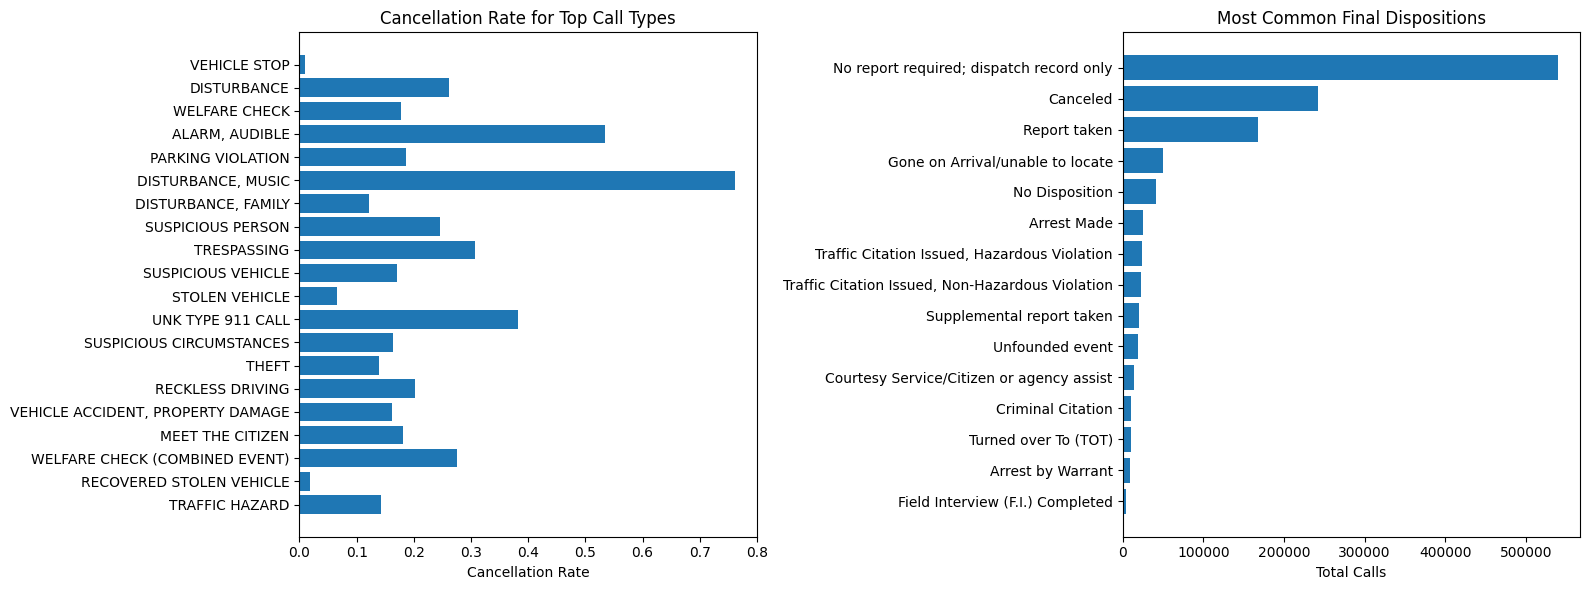

In [14]:
call_type_profile = (
    df.groupby("CALL_TYPE", observed=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum"),
          priority_1_calls=("is_p1", "sum")
      )
)
call_type_profile["cancel_rate"] = np.where(
    call_type_profile["total_calls"] > 0,
    call_type_profile["canceled_calls"] / call_type_profile["total_calls"],
    np.nan
)
call_type_profile["priority_1_share"] = np.where(
    call_type_profile["total_calls"] > 0,
    call_type_profile["priority_1_calls"] / call_type_profile["total_calls"],
    np.nan
)
call_type_profile = (
    call_type_profile.sort_values("total_calls", ascending=False)
                     .head(20)
                     .reset_index()
)

disposition_profile = (
    df.groupby("FINAL_DISPO", observed=False)
      .agg(total_calls=("CDTS", "size"))
      .sort_values("total_calls", ascending=False)
      .head(15)
      .reset_index()
)

display(call_type_profile)
display(disposition_profile)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(call_type_profile["CALL_TYPE"].iloc[::-1], call_type_profile["cancel_rate"].iloc[::-1])
axes[0].set_title("Cancellation Rate for Top Call Types")
axes[0].set_xlabel("Cancellation Rate")

axes[1].barh(disposition_profile["FINAL_DISPO"].iloc[::-1], disposition_profile["total_calls"].iloc[::-1])
axes[1].set_title("Most Common Final Dispositions")
axes[1].set_xlabel("Total Calls")

plt.tight_layout()
plt.show()

## Inspect one high-demand event window

In [15]:
if not top_stress_windows.empty:
    selected_window = top_stress_windows.iloc[0]["time_bin"]
    start_window = selected_window - pd.Timedelta(minutes=30)
    end_window = selected_window + pd.Timedelta(minutes=30)

    event_slice = df[(df["CDTS"] >= start_window) & (df["CDTS"] <= end_window)].copy()
    event_slice = event_slice.sort_values("CDTS")

    print("High-demand window:", start_window, "to", end_window)
    print("Calls in window:", len(event_slice))

    cols_to_show = ["CDTS", "PRIORITY", "CALL_TYPE", "FINAL_DISPO"]
    if "ADDRESS" in event_slice.columns:
        cols_to_show.append("ADDRESS")
    if "CITY" in event_slice.columns:
        cols_to_show.append("CITY")

    display(event_slice[cols_to_show])

High-demand window: 2026-03-28 23:15:00 to 2026-03-29 00:15:00
Calls in window: 245


,CDTS,PRIORITY,CALL_TYPE,FINAL_DISPO,ADDRESS,CITY
1176854,2026-03-28 23:15:03,6,VEHICLE STOP,"Traffic Citation Issued, Non-Hazardous Violation",SENTER RD & EZIE ST,San Jose
1176855,2026-03-28 23:15:03,6,VEHICLE STOP,"Traffic Citation Issued, Non-Hazardous Violation",SENTER RD & EZIE ST,San Jose
1176856,2026-03-28 23:15:03,6,VEHICLE STOP,"Traffic Citation Issued, Non-Hazardous Violation",SENTER RD & EZIE ST,San Jose
1176857,2026-03-28 23:16:11,3,"DISTURBANCE, FAMILY",No report required; dispatch record only,[5700]-[5800] VIA MONTE DR,San Jose
1176858,2026-03-28 23:16:17,6,PEDESTRIAN STOP,No report required; dispatch record only,S 1ST ST & KEYES ST,San Jose
...,...,...,...,...,...,...
1177095,2026-03-29 00:13:52,3,MALICIOUS MISCHIEF,Report taken,[1700]-[1800] E CAPITOL EX,San Jose
1177094,2026-03-29 00:13:52,3,MALICIOUS MISCHIEF,Report taken,[1700]-[1800] E CAPITOL EX,San Jose
1177096,2026-03-29 00:13:52,3,MALICIOUS MISCHIEF,Report taken,[1700]-[1800] E CAPITOL EX,San Jose
1177097,2026-03-29 00:14:42,1,ASSAULT WITH DEADLY WEAPON,Report taken,[1300]-[1400] S BASCOM AV,San Jose


## Detailed calls inside the selected high-demand window

,CALL_TYPE,total_calls
0,VEHICLE STOP,81
1,"DISTURBANCE, MUSIC",39
2,DISTURBANCE,16
3,SUSPICIOUS VEHICLE,15
4,MALICIOUS MISCHIEF,6
5,WELFARE CHECK,6
6,PEDESTRIAN STOP,6
7,TRESPASSING,6
8,MENTALLY DISTURBED PERSON,6
9,UNK TYPE 911 CALL,6


,PRIORITY,total_calls
0,1,8
1,2,37
2,3,56
3,4,48
4,5,9
5,6,87


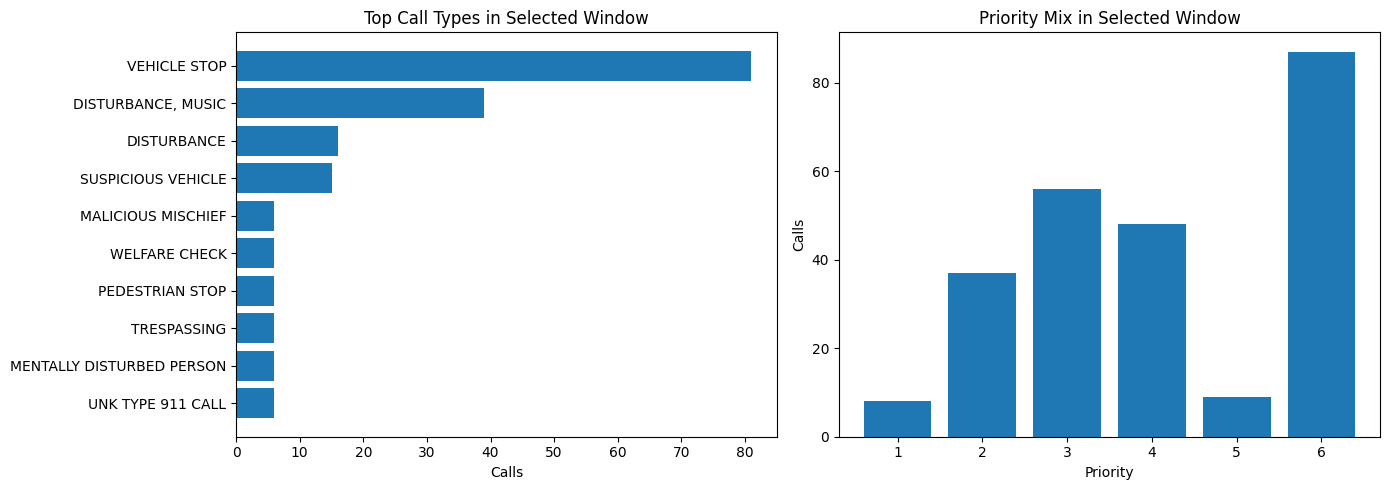

In [16]:
if not top_stress_windows.empty and not event_slice.empty:
    window_call_mix = (
        event_slice.groupby("CALL_TYPE", observed=False)
                  .size()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index(name="total_calls")
    )

    window_priority_mix = (
        event_slice.groupby("PRIORITY", observed=False)
                  .size()
                  .sort_index()
                  .reset_index(name="total_calls")
    )

    display(window_call_mix)
    display(window_priority_mix)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(window_call_mix["CALL_TYPE"].iloc[::-1], window_call_mix["total_calls"].iloc[::-1])
    axes[0].set_title("Top Call Types in Selected Window")
    axes[0].set_xlabel("Calls")

    axes[1].bar(window_priority_mix["PRIORITY"].astype(str), window_priority_mix["total_calls"])
    axes[1].set_title("Priority Mix in Selected Window")
    axes[1].set_xlabel("Priority")
    axes[1].set_ylabel("Calls")

    plt.tight_layout()
    plt.show()

## Build monthly and yearly workload summaries

,year,month,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,2022,1,23348,4164,738,0.178345,0.031609
1,2022,2,21332,3418,635,0.160229,0.029767
2,2022,3,25315,4225,710,0.166897,0.028047
3,2022,4,23553,4388,676,0.186303,0.028701
4,2022,5,27064,4867,845,0.179833,0.031222
5,2022,6,26030,4616,875,0.177334,0.033615
6,2022,7,23623,4495,746,0.190281,0.031579
7,2022,8,26737,4475,824,0.167371,0.030819
8,2022,9,26074,4700,891,0.180256,0.034172
9,2022,10,26065,4795,821,0.183963,0.031498


,year,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,2022,294473,52013,9183,0.176631,0.031185
1,2023,286471,57327,9296,0.200114,0.032450
2,2024,272508,57694,8894,0.211715,0.032638
3,2025,262109,56405,8266,0.215197,0.031536
4,2026,91322,19265,2511,0.210957,0.027496


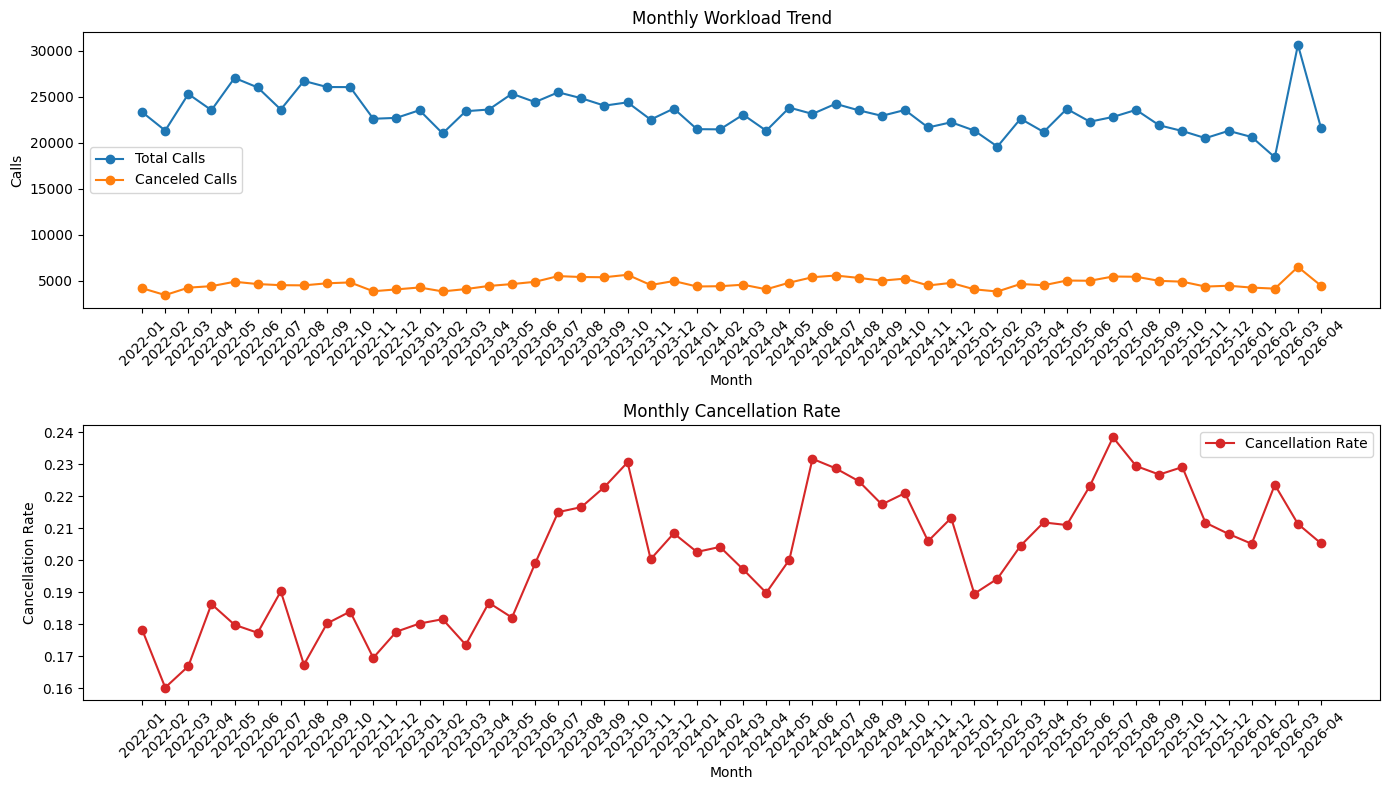

In [17]:
monthly_summary = (
    df.groupby(["year", "month"], observed=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum"),
          priority_1_calls=("is_p1", "sum")
      )
      .reset_index()
)

monthly_summary["cancel_rate"] = np.where(
    monthly_summary["total_calls"] > 0,
    monthly_summary["canceled_calls"] / monthly_summary["total_calls"],
    np.nan
)
monthly_summary["priority_1_share"] = np.where(
    monthly_summary["total_calls"] > 0,
    monthly_summary["priority_1_calls"] / monthly_summary["total_calls"],
    np.nan
)

yearly_summary = (
    df.groupby("year", observed=False)
      .agg(
          total_calls=("CDTS", "size"),
          canceled_calls=("is_canceled", "sum"),
          priority_1_calls=("is_p1", "sum")
      )
      .reset_index()
)

yearly_summary["cancel_rate"] = np.where(
    yearly_summary["total_calls"] > 0,
    yearly_summary["canceled_calls"] / yearly_summary["total_calls"],
    np.nan
)
yearly_summary["priority_1_share"] = np.where(
    yearly_summary["total_calls"] > 0,
    yearly_summary["priority_1_calls"] / yearly_summary["total_calls"],
    np.nan
)

monthly_summary = monthly_summary.sort_values(["year", "month"]).reset_index(drop=True)
yearly_summary = yearly_summary.sort_values("year").reset_index(drop=True)

display(monthly_summary)
display(yearly_summary)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

month_labels = monthly_summary["year"].astype(str) + "-" + monthly_summary["month"].astype(str).str.zfill(2)
axes[0].plot(month_labels, monthly_summary["total_calls"], marker="o", label="Total Calls")
axes[0].plot(month_labels, monthly_summary["canceled_calls"], marker="o", label="Canceled Calls")
axes[0].set_title("Monthly Workload Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Calls")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].plot(month_labels, monthly_summary["cancel_rate"], marker="o", color="tab:red", label="Cancellation Rate")
axes[1].set_title("Monthly Cancellation Rate")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cancellation Rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## Print a compact workload EDA summary

In [18]:
busiest_day_row = daily_calls.loc[daily_calls["total_calls"].idxmax()]
top_call_type_row = call_type_profile.iloc[0] if not call_type_profile.empty else None
top_address_row = top_addresses.iloc[0] if not top_addresses.empty else None

summary_stats = {
    "total_rows_after_cleaning": int(len(df)),
    "date_min": df["CDTS"].min(),
    "date_max": df["CDTS"].max(),
    "total_canceled_calls": int(df["is_canceled"].sum()),
    "overall_cancel_rate": float(df["is_canceled"].mean()),
    "busiest_day": busiest_day_row["day"],
    "busiest_day_calls": int(busiest_day_row["total_calls"]),
    "avg_calls_per_day": float(daily_calls["total_calls"].mean()),
    "top_call_type": None if top_call_type_row is None else top_call_type_row["CALL_TYPE"],
    "top_call_type_volume": None if top_call_type_row is None else int(top_call_type_row["total_calls"]),
    "top_address": None if top_address_row is None else top_address_row["ADDRESS"],
    "top_address_volume": None if top_address_row is None else int(top_address_row["total_calls"])
}

print("\nWorkload EDA Summary Stats")
for key, value in summary_stats.items():
    print(f"{key}: {value}")


Workload EDA Summary Stats
total_rows_after_cleaning: 1206883
date_min: 2022-01-01 00:03:07
date_max: 2026-04-27 06:29:31
total_canceled_calls: 242704
overall_cancel_rate: 0.20109985806412056
busiest_day: 2026-03-29 00:00:00
busiest_day_calls: 2963
avg_calls_per_day: 766.2749206349206
top_call_type: VEHICLE STOP
top_call_type_volume: 126770
top_address: [2800]-[2900] STEVENS CREEK BL 
top_address_volume: 6260
